## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('/data/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("/data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)


### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

# PART 1

In [1]:

import pandas as pd

# Mortality file (pre-cleaned)
mdf = pd.read_csv("data/linked_mortality_file_1999_2000.csv")

# NHANES XPT files
gdf = pd.read_sas("data/DEMO.xpt", format="xport")   # demographics
bmx = pd.read_sas("data/BMX.xpt",  format="xport")   # body measures
smq = pd.read_sas("data/SMQ.xpt",  format="xport")   # smoking questionnaire
diq = pd.read_sas("data/DIQ.xpt",  format="xport")   # diabetes questionnaire
bpq = pd.read_sas("data/BPQ.xpt",  format="xport")   # blood pressure questionnaire
lab = pd.read_sas("data/LAB13.xpt",format="xport")   # labs (cholesterol etc.)
mcq = pd.read_sas("data/MCQ.xpt",  format="xport")   # medical conditions (CVD history)

# Ensure SEQN is consistent (safe)
for d in [gdf, bmx, smq, diq, bpq, lab, mcq]:
    d["SEQN"] = d["SEQN"].astype(int)
mdf["SEQN"] = mdf["SEQN"].astype(int)

# Merge (inner join to mortality-linked sample, then left join other NHANES modules)
df = gdf.merge(mdf, on="SEQN", how="inner")
df = df.merge(bmx, on="SEQN", how="left")
df = df.merge(smq, on="SEQN", how="left")
df = df.merge(diq, on="SEQN", how="left")
df = df.merge(bpq, on="SEQN", how="left")
df = df.merge(lab, on="SEQN", how="left")
df = df.merge(mcq, on="SEQN", how="left")

# Keep only those eligible for mortality linkage
df = df[df["ELIGSTAT"] == 1].copy()

print("Merged + ELIGSTAT==1 shape:", df.shape)
df[["SEQN","ELIGSTAT","MORTSTAT","PERMTH_INT","RIDAGEYR","RIAGENDR"]].head()

Merged + ELIGSTAT==1 shape: (5445, 447)


,SEQN,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEYR,RIAGENDR
1,2,1,1.0,177.0,77.0,1.0
4,5,1,0.0,244.0,49.0,1.0
5,6,1,0.0,246.0,19.0,2.0
6,7,1,0.0,237.0,59.0,2.0
9,10,1,1.0,231.0,43.0,1.0


The `ELIGSTAT` variable represents linkage eligibility for a mortality follow-up . A 1 indicates that the survey participant was eligible for the mortality linkage; 2 indicates the survey participant was underage and therefore not eligible; 3 indicates that the survey participant was not linkage eligible due to insufficient data. The `MORTSTAT` variable  represents the determination of vital status. `PERMTH_INT` represents the follow-up time calculated using the
months from the date of interview to the date of death. Lastly, `RIDAGEEX` indicates the best age in months at the date of examination, for individuals under 85 years at screening.

In [2]:
df.isna().sum()

SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIDEXMON     472
RIAGENDR       0
            ... 
MCQ260GH    5413
MCQ260GI    5358
MCQ270       570
MCQ280      5197
MCQ290      5436
Length: 447, dtype: int64

## About Missing Data
Core demographic variables such as `SEQN`, `SDDSRVYR`, `RIDSTATR`, and `RIAGENDR` contain no missing values, indicating complete baseline demographic information for eligible participants. Some laboratory variables, such as total cholesterol (`LBXTC`), exhibit moderate missingness, likely due to non-participation in the laboratory examination component. Certain questionnaire variables in the full merged dataset show substantial missingness due to skip patterns or survey nonresponse; however, these variables were not retained for modeling.

When focusing on the selected predictor set (df1), all retained variables exhibit less than approximately 20% missingness. This preserves sample size while ensuring reasonable data completeness for subsequent modeling.

In [3]:
# Choose predictors + targets (keep list)
keep = [
    "SEQN",
    "MORTSTAT", "PERMTH_INT",
    "RIDAGEYR", "RIAGENDR", "RIDRETH1",   # demographics
    "BMXBMI",                            # body measures
    "SMQ020",                            # ever smoked
    "DIQ010",                            # diabetes
    "BPQ020",                            # told high blood pressure
    "LBXTC",                             # total cholesterol
    # medical conditions for composite CVD history:
    "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E"
]

df1 = df[keep].copy()

# Composite cardiovascular disease history: CHF, CHD, angina, heart attack (1=yes, 2=no)
cvd_vars = ["MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E"]
df1["CVD_HISTORY"] = (df1[cvd_vars] == 1).any(axis=1).astype(int)

# Drop the individual MCQ variables after creating the composite
df1 = df1.drop(columns=cvd_vars)

# Recode NHANES yes/no: 1=yes -> 1, 2=no -> 0, other -> NaN
yn_map = {1: 1, 2: 0}
for col in ["SMQ020", "DIQ010", "BPQ020"]:
    df1[col] = df1[col].map(yn_map)

# Gender mapping (keep as category for EDA; later one-hot for kNN)
df1["RIAGENDR"] = df1["RIAGENDR"].map({1: "Male", 2: "Female"})

df1.head()

,SEQN,MORTSTAT,PERMTH_INT,RIDAGEYR,RIAGENDR,RIDRETH1,BMXBMI,SMQ020,DIQ010,BPQ020,LBXTC,CVD_HISTORY
1,2,1.0,177.0,77.0,Male,3.0,24.90,0.0,0.0,0.0,215.0,0
4,5,0.0,244.0,49.0,Male,3.0,29.10,1.0,0.0,1.0,279.0,0
5,6,0.0,246.0,19.0,Female,5.0,22.56,NaN,0.0,0.0,153.0,0
6,7,0.0,237.0,59.0,Female,4.0,29.39,1.0,0.0,1.0,245.0,0
9,10,1.0,231.0,43.0,Male,4.0,30.94,1.0,0.0,0.0,140.0,0


## Predictor Selection
We selected baseline demographic and health variables that are well-established predictors of mortality. These include age, gender, and race/ethnicity (demographics); BMI (body composition); smoking status; self-reported diabetes and hypertension; and total cholesterol levels.

To better capture cardiovascular risk, we constructed a composite cardiovascular disease indicator using self-reported physician diagnoses of congestive heart failure, coronary heart disease, angina, or heart attack (MCQ160B–MCQ160E). This composite variable (CVD_HISTORY) allows us to incorporate cardiovascular history without introducing redundant predictors.

All selected variables exhibit less than 20% missingness, preserving sample size for modeling.

In [4]:
missing = df1.isna().mean().sort_values(ascending=False)
missing

LBXTC          0.152250
SMQ020         0.107071
BMXBMI         0.100092
BPQ020         0.015060
DIQ010         0.011754
PERMTH_INT     0.000000
MORTSTAT       0.000000
SEQN           0.000000
RIDAGEYR       0.000000
RIDRETH1       0.000000
RIAGENDR       0.000000
CVD_HISTORY    0.000000
dtype: float64

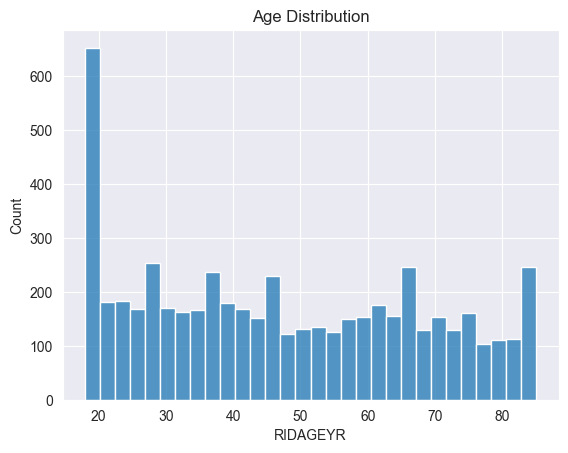

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df1["RIDAGEYR"], bins=30)
plt.title("Age Distribution")
plt.xlabel("RIDAGEYR")
plt.show()

### Age Distribution
The age distribution spans about 18 to 85 years, with observations relatively spread across adulthood. There's a noticeable concentration in younger age groups (~late teens to early 20s), reflecting the survey’s sampling structure. Overall, the distribution does not appear strongly skewed, though there is a natural upper boundary due to the survey’s age cap.

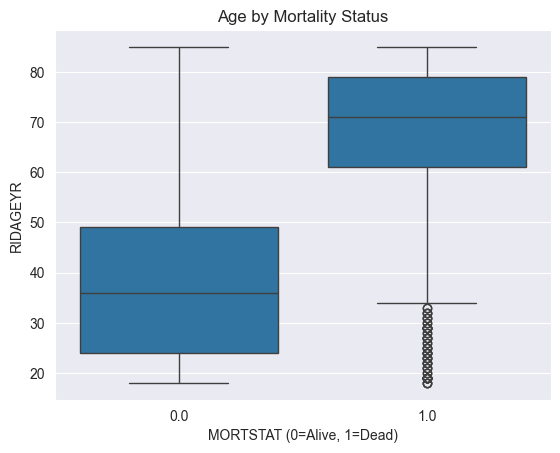

In [6]:
sns.boxplot(x="MORTSTAT", y="RIDAGEYR", data=df1)
plt.title("Age by Mortality Status")
plt.xlabel("MORTSTAT (0=Alive, 1=Dead)")
plt.show()

### Age by Mortality Status
The boxplot shows a strong association between age and mortality. Participants who died during follow-up (`MORTSTAT` = 1) are substantially older at baseline, with a median age around the early 70s, compared to a median age in the mid-30s among survivors. The interquartile ranges also show limited overlap, indicating that age is a powerful predictor of mortality in this dataset. A small number of younger individuals appear among decedents, visible as lower-age outliers in the mortality group, but the overall pattern clearly demonstrates increasing mortality risk with age.

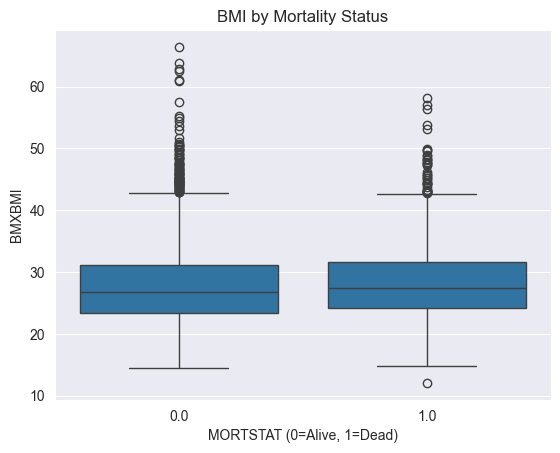

In [7]:
# BMI by mortality status
sns.boxplot(x="MORTSTAT", y="BMXBMI", data=df1)
plt.title("BMI by Mortality Status")
plt.xlabel("MORTSTAT (0=Alive, 1=Dead)")
plt.show()

### BMI and Mortality Status
The BMI distributions for survivors and decedents are broadly similar, with medians in the overweight range (approximately 26–28). While decedents appear to have a slightly higher median BMI, the interquartile ranges overlap almost exactly, suggesting BMI alone The BMI distributions for survivors and decedents are broadly similar, with medians in the overweight range (approximately 26–28). While decedents appear to have a slightly higher median BMI, the interquartile ranges overlap substantially, suggesting that BMI alone is not as strong a predictor of mortality as age. Both groups exhibit high-BMI outliers, indicating the presence of severe obesity within the sample. Notably, among decedents there is a visible concentration of observations in the higher BMI range (approximately 44–50), suggesting that severe obesity may be more prevalent among individuals who died during follow-up. Although the boxplot does not establish causality, this pattern is consistent with established evidence linking obesity to elevated cardiovascular and metabolic risk. Overall, BMI may contribute to mortality risk but does not display as strong a separation between groups as age.is not as strong a predictor of mortality as age. Both groups exhibit high-BMI outliers (above 50), indicating the presence of severe obesity in the sample. Overall, BMI may contribute to mortality risk but does not display as strong a separation between groups as age.

In [8]:
# Smoking status by mortality status
pd.crosstab(df1["SMQ020"], df1["MORTSTAT"], normalize="index")

MORTSTAT,0.0,1.0
SMQ020,,
0.0,0.717349,0.282651
1.0,0.595995,0.404005


### Smoking and Mortality Status
The contingency table indicates a clear association between smoking and mortality. Among participants who had ever smoked (SMQ020 = 1), approximately 40% died during follow-up, compared to roughly 28% among non-smokers. This suggests that smoking is associated with increased mortality risk in this cohort and may serve as an important predictor in classification models.

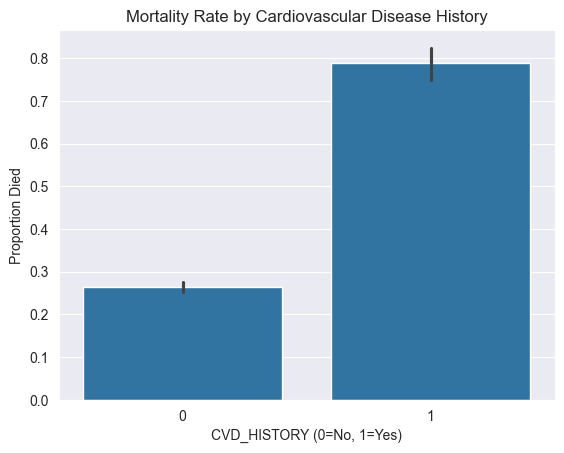

In [9]:
sns.barplot(x="CVD_HISTORY", y="MORTSTAT", data=df1)
plt.title("Mortality Rate by Cardiovascular Disease History")
plt.ylabel("Proportion Died")
plt.xlabel("CVD_HISTORY (0=No, 1=Yes)")
plt.show()

### Cardiovascular Disease History and Mortality

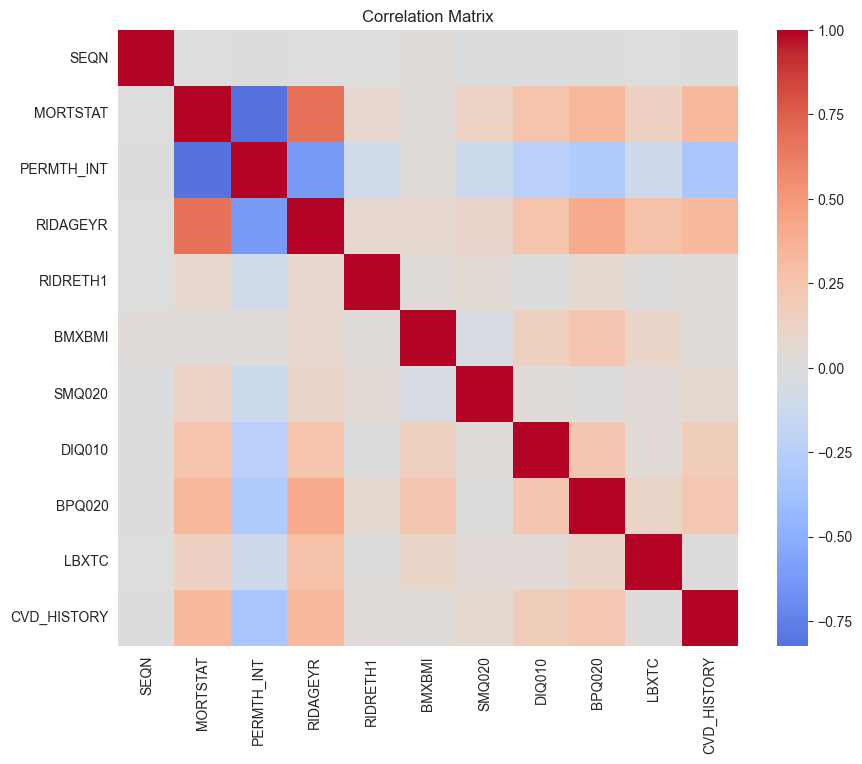

In [10]:
import numpy as np

corr = df1.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix
The correlation matrix confirms several expected relationships. Age (RIDAGEYR) shows a strong positive correlation with mortality, reinforcing its importance as a predictor. The composite cardiovascular disease indicator (CVD_HISTORY) is also positively associated with mortality, reflecting elevated risk among individuals with prior cardiovascular diagnoses.

Chronic conditions such as diabetes and hypertension are moderately correlated with both age and mortality, consistent with established epidemiological patterns.

## Summary of Exploratory Findings from Part 1
Exploratory analysis indicates that age is the strongest predictor of mortality in this cohort, with substantial separation between survivors and decedents. Smoking and cardiovascular disease history also demonstrate meaningful associations with mortality, while diabetes and hypertension show moderate relationships consistent with known health risk pathways. BMI and cholesterol exhibit weaker but plausible patterns.

Distributions reveal some skewness and high-value outliers in BMI and cholesterol, though no extreme anomalies are observed. Correlation analysis suggests limited redundancy among predictors, supporting their suitability for k-NN modeling. Overall, the selected demographic and health variables provide a biologically plausible and statistically reasonable feature set for subsequent mortality prediction.

# PART 2

## Describing the Data

In [11]:
df_model = df1.dropna()
print(df_model.shape)

#Look at missing proportions; in part 1 but reprinted for readability

missing_prop = df1.isna().mean()

print("Proportion Missing (%):", (missing_prop * 100))

#sample size before removal
obs_before = df1.shape[0]
print("Initial modeling sample size:", obs_before)

df_model = df1.dropna().copy()
obs_after = df_model.shape[0]

#sample size after removal
print("Sample size after dropping missing:", obs_after)

#what exactly did we lose?
diff = obs_before - obs_after
print("Lost observations (Difference):",diff)
print("Percent Lost:", ((diff)/obs_before) * 100, "%")

(3972, 12)
Proportion Missing (%): SEQN            0.000000
MORTSTAT        0.000000
PERMTH_INT      0.000000
RIDAGEYR        0.000000
RIAGENDR        0.000000
RIDRETH1        0.000000
BMXBMI         10.009183
SMQ020         10.707071
DIQ010          1.175390
BPQ020          1.505969
LBXTC          15.224977
CVD_HISTORY     0.000000
dtype: float64
Initial modeling sample size: 5445
Sample size after dropping missing: 3972
Lost observations (Difference): 1473
Percent Lost: 27.052341597796143 %


This data frame of our chosen variables consists of 3972 rows and 12 columns. The rows or observations represent a NHANES participant of their study. The National Center for Health Statistics (NCHS) linked their past data together to formulate the linked mortality files (lmf). The NCHS created public useage of these files for National Health Interview Survey(NHIS) and National Health and Nutrion Examination Survey(NHANES). The NCHS released this data for NHANES to conduct further research on mortality including different causes or reasonings behind death in the nation.

Below we have observed missingness of our new dataframe of selected variables for modeling. After removing NAs, the data frame lost 1473 observations. This means about 27% of the data was removed. As previously mentioned in part one, none of the variables have more than 20 percent missingness. Although this amount allows for modeling, if the missingness is not at random the k-NN might be influenced. Additionally, this bias might not accurately represent the entire population.

There a some known limitations to analysis that should be acknowledged. First, the data presented by NHANES is observational so model building and correlation plots cannot demonstrate causation. Another limitation from the study itself is information that is self-reported or inaccurately measured could lead to bias. In addition, this study used sampling weights for complex survey design. This type of sampling could lead to overfitting as the k-NN is more receptive to closer neighbors than further ones. Lastly, k-NN modeling can be influenced strongly by the size and shape of the dataset. Skew, a large number of ranged predictor variables, or an abundance of outliers can all influence the accuracy and capabilities of modeling.

# Rationale behind predictors

We selected demographic and baseline health variables that are commonly linked to mortality risk and life expectancy. These include age, sex, and race/ethnicity to capture basic population differences in health outcomes. Age in particular is known to be one of the strongest predictors of mortality, since the risk of death generally increases with older age.

We also included BMI, smoking history, diabetes, hypertension, and total cholesterol as indicators of behavioral and cardiovascular health. These factors are widely associated with chronic disease and long-term health risk. To better summarize serious heart-related conditions, we created a composite cardiovascular disease indicator (CVD_HISTORY) based on prior diagnoses such as heart attack or coronary heart disease.

Overall, these variables provide a reasonable mix of demographic and health-related risk factors that are biologically meaningful and suitable for predicting both mortality status and survival time using k-NN models.


# Analysis

              SEQN     MORTSTAT   PERMTH_INT     RIDAGEYR     RIDRETH1  \
count  3972.000000  3972.000000  3972.000000  3972.000000  3972.000000   
mean   4999.264350     0.311934   204.965509    49.569990     2.636707   
std    2862.878335     0.463341    63.017120    18.656969     1.144196   
min       2.000000     0.000000     1.000000    20.000000     1.000000   
25%    2482.000000     0.000000   199.000000    33.000000     1.000000   
50%    4995.500000     0.000000   235.000000    48.000000     3.000000   
75%    7467.250000     1.000000   242.000000    65.000000     3.000000   
max    9965.000000     1.000000   250.000000    85.000000     5.000000   

            BMXBMI       SMQ020       DIQ010       BPQ020        LBXTC  \
count  3972.000000  3972.000000  3972.000000  3972.000000  3972.000000   
mean     28.413454     0.471299     0.094159     0.297835   205.467019   
std       6.234180     0.499238     0.292087     0.457364    41.438624   
min      14.420000     0.000000     0

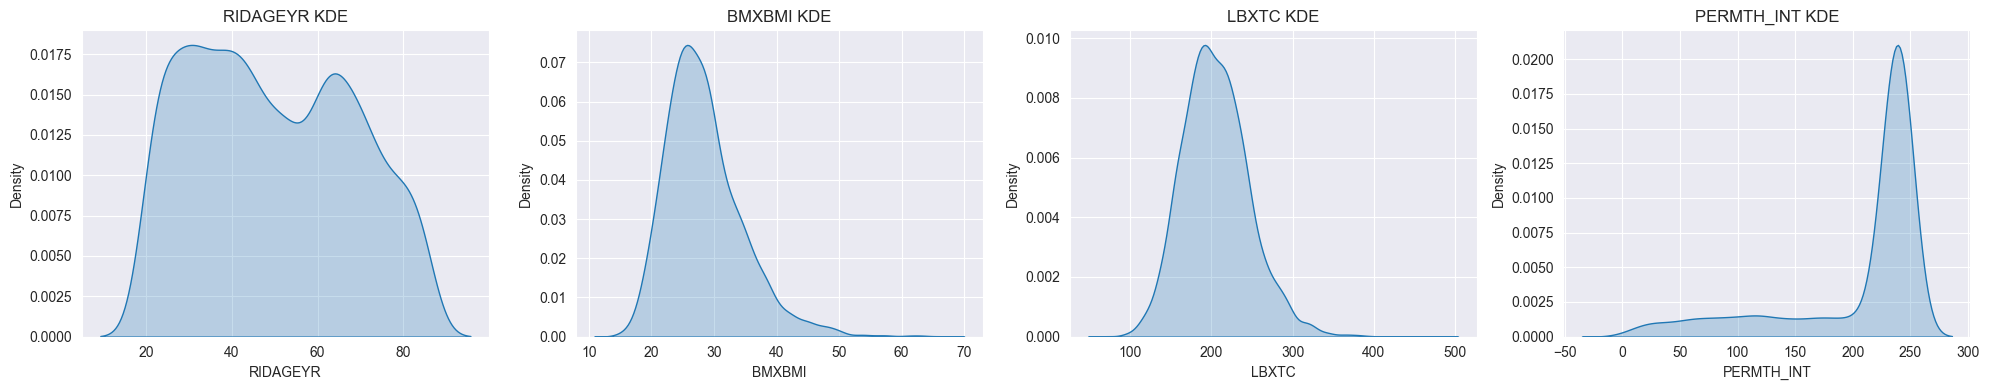

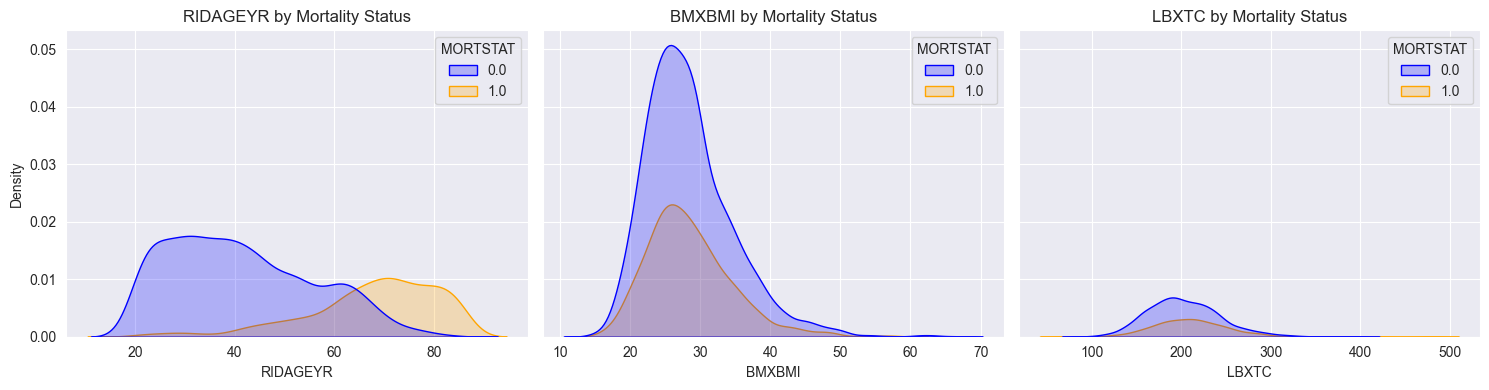

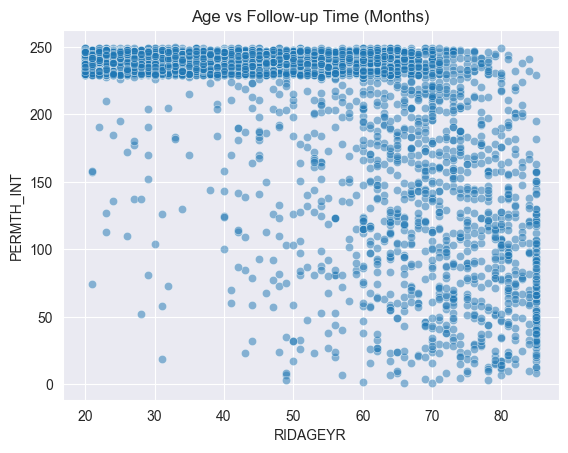

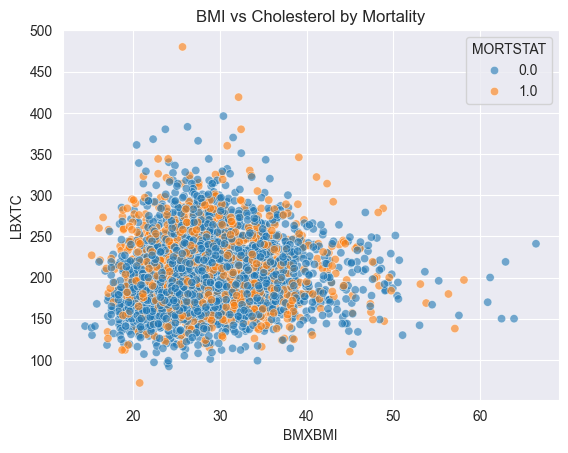

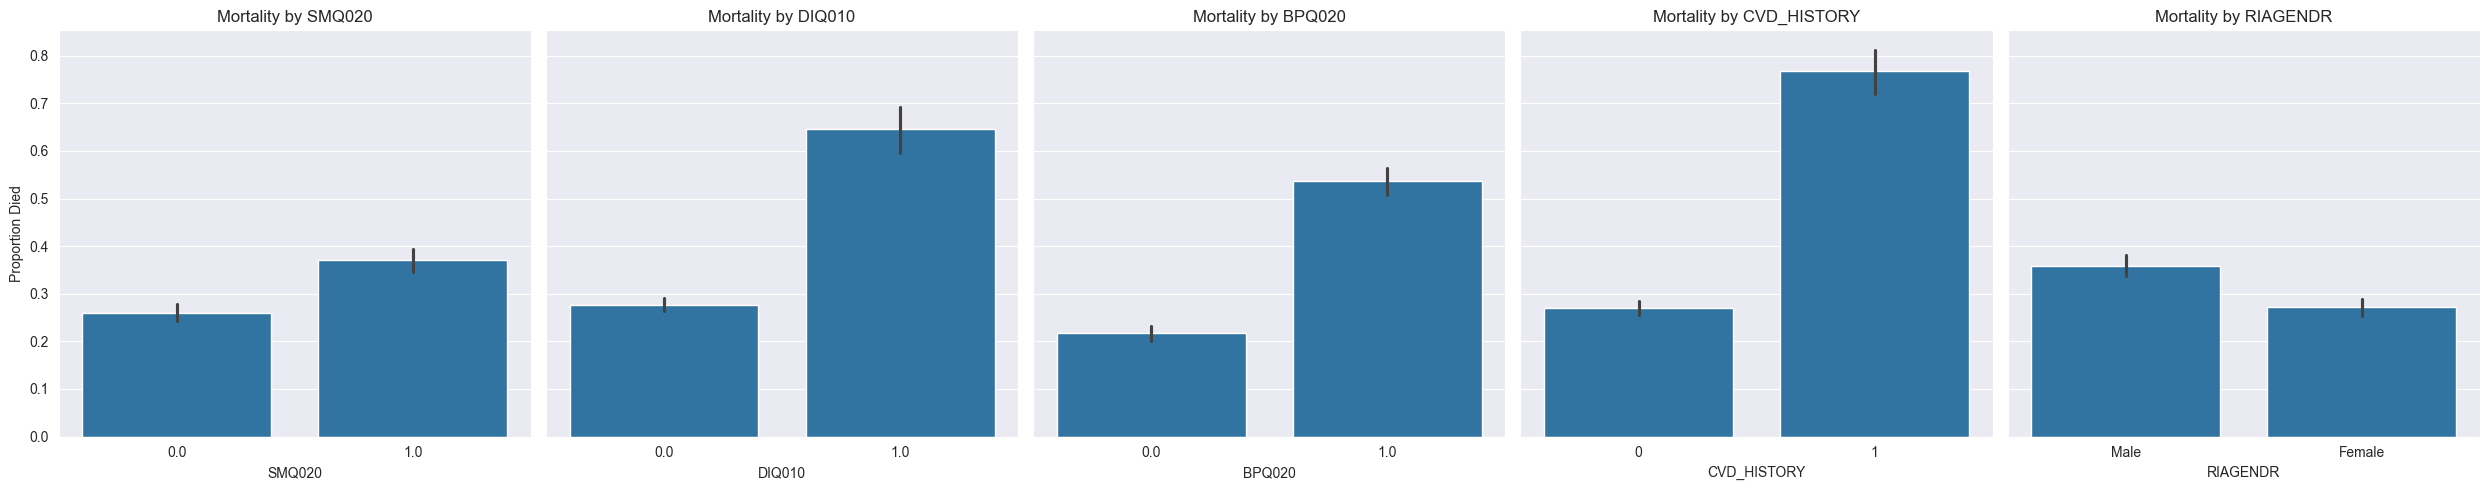

In [12]:
# Summary
print(df_model.describe())

# Summary by Mortality Status
print(df_model.groupby("MORTSTAT").describe())

# Kernel Density Plot of age, bmi, cholesterol, and survival time
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = ["RIDAGEYR", "BMXBMI", "LBXTC", "PERMTH_INT"]
n_vars = len(num_vars)

# subplots
fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 4))

for ax, v in zip(axes, num_vars):
    sns.kdeplot(data=df_model, x=v, fill=True, ax=ax)
    ax.set_title(f"{v} KDE")
    ax.set_xlabel(v)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

# Conditional Kernel Densities of age, bmi, and cholsterol
num_vars = ["RIDAGEYR", "BMXBMI", "LBXTC"]
n_vars = len(num_vars)

fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 4), sharey=True)

for ax, v in zip(axes, num_vars):
    sns.kdeplot(data=df_model, x=v, hue="MORTSTAT", fill=True, ax=ax, palette={0:"blue", 1:"orange"})
    ax.set_title(f"{v} by Mortality Status")
    ax.set_xlabel(v)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


# Age vs Survival Time
plt.figure()
sns.scatterplot(data=df_model, x="RIDAGEYR", y="PERMTH_INT", alpha=0.5)
plt.title("Age vs Follow-up Time (Months)")
plt.show()

# BMI vs Cholesterol
plt.figure()
sns.scatterplot(
    data=df_model,
    x="BMXBMI",
    y="LBXTC",
    hue="MORTSTAT",
    alpha=0.6
)
plt.title("BMI vs Cholesterol by Mortality")
plt.show()

# Smoking mortality rate
pd.crosstab(df_model["SMQ020"], df_model["MORTSTAT"], normalize="index")

# Barplot (smoking, diabetes status, high blood pressure, cardivascular disease, age)
cat_vars = ["SMQ020", "DIQ010", "BPQ020", "CVD_HISTORY", "RIAGENDR"]
n_vars = len(cat_vars)

# subplots
fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 5), sharey=True)

for ax, v in zip(axes, cat_vars):
    sns.barplot(data=df_model, x=v, y="MORTSTAT", ax=ax)
    ax.set_title(f"Mortality by {v}")
    ax.set_ylabel("Proportion Died")
    ax.set_xlabel(v)

plt.tight_layout()
plt.show()



# Patterns

First, looking at the kernel density plots, the age distribution appears somewhat bimodal, reflecting the presence of both younger and older adult groups in the sample. The BMI and cholesterol KDE plots showed similar shapes, a single central peak with moderate spread and a few higher value observations. The survivial time KDE displays a large left-skew with most participants having longer survival durations and fewer observations at shorter times.

Next, looking at the distribution plots by mortality status, age appears to have a significant seperation. There is an intersection  between age and mortality at approximately 65. Survivors tend to be younger, peaking in their early 30s, while decedents peak in their early 70s. There is very little overlap between the two groups, showing a clear distinction in age distributions. This pattern suggests that age is one of the strongest indicators of mortality in this dataset. For BMI, both survivors and decedents show a slightly right-skewed distribution centered around 25–28. Decedents have a slightly broader spread and more extreme high-BMI values. While very high BMI may indicate increased risk, the two groups overlap substantially, suggesting BMI alone may not strongly distinguish mortality in this dataset. Lastly, for cholesterol, survivors and decedents have very similar cholesterol distributions, both roughly centered around 200 mg/dL. In this dataset, cholesterol alone does not appear to separate the two groups, though it may still contribute useful information when considered alongside other variables.

Next, we are looking at the comparison graph between Age and Survival Time. Most participants have follow-up times near the top of the Y-axis (~240+ months), indicating they survived the entire study period. As age increases, there is a growing density of points below that top line, representing participants whose follow-up ended early due to death. This pattern shows that older participants not only have higher mortality rates, but also tend to die earlier in the follow-up period. It confirms that age is a strong indicator of both whether and when participants die during the study. For the BMI and Cholesterol graph by mortality, points for survivors and decedents largely overlap in the center of the plot, with no clear trend along a diagonal or clustering of decedents in one region. BMI and cholesterol do not appear strongly correlated in this sample.

Finally, we have the bar plots of smoking, diabetes status, high blood pressure, cardivascular disease, and age compared to the mortality rate. The plots for cardivascular disease, diabetes status, and high blood pressure appear similarly, with individuals with a positive diagnosis for these conditions have a significantly higher mortality rate than those without. The smoking plot indicates that smoekrs have a higher mortality rate than those without. For gender, males appear to have a higher mortality rate compared to females.

## k-Nearest Neighbor Classifier for Mortality Prediction

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np

# Define features (X) and target (y)
X = df_model.drop(columns=["SEQN", "MORTSTAT", "PERMTH_INT"])
y = df_model["MORTSTAT"]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

# Create a preprocessing pipeline for numerical and categorical features
# Numerical features will be scaled, categorical features will be one-hot encoded
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Numerical Features: ['RIDAGEYR', 'RIDRETH1', 'BMXBMI', 'SMQ020', 'DIQ010', 'BPQ020', 'LBXTC', 'CVD_HISTORY']
Categorical Features: ['RIAGENDR']
X_train shape: (2780, 9)
X_test shape: (1192, 9)


C:\Users\zayta\AppData\Local\Temp\ipykernel_21868\4280774435.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist()


### Selecting Optimal k using Cross-Validation

We will use GridSearchCV to systematically search for the best k value. We will evaluate k values from 1 to 30 using 5-fold cross-validation and choose the k that yields the highest accuracy.

Optimal k: 21
Best cross-validation accuracy: 0.8363


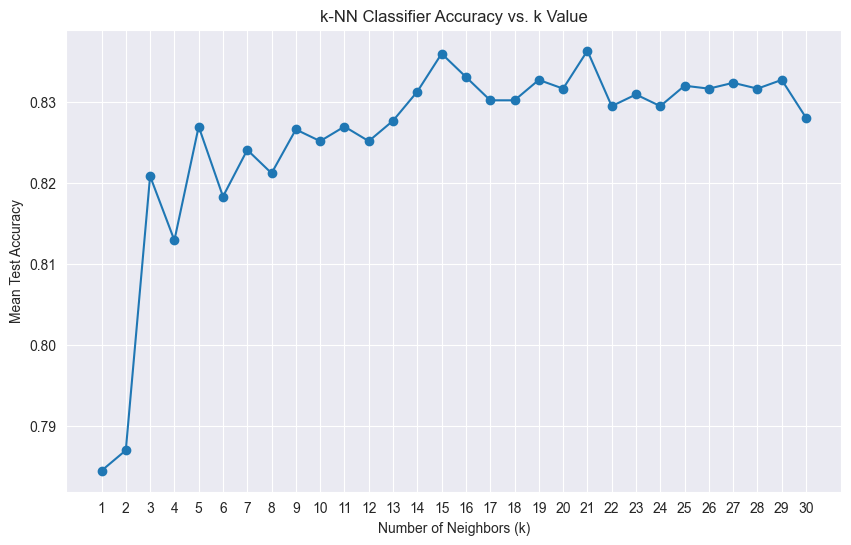

In [14]:
# Create the k-NN classifier pipeline
k_range = list(range(1, 31))

pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier())])

param_grid = {'classifier__n_neighbors': k_range}

# Perform GridSearchCV to find the optimal k
grid_search = GridSearchCV(pipeline_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best k and its corresponding score
best_k = grid_search.best_params_['classifier__n_neighbors']
best_score = grid_search.best_score_

print(f"Optimal k: {best_k}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Plot the accuracy for different k values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_range, grid_search.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Test Accuracy')
plt.title('k-NN Classifier Accuracy vs. k Value')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Training and Evaluating the k-NN Classifier with Optimal k

Now, we have to train the k-NN classifier using the optimal k found from cross-validation and evaluate its performance on the test set.

Test Set Accuracy: 0.8389

Confusion Matrix:
[[754  66]
 [126 246]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89       820
         1.0       0.79      0.66      0.72       372

    accuracy                           0.84      1192
   macro avg       0.82      0.79      0.80      1192
weighted avg       0.84      0.84      0.83      1192



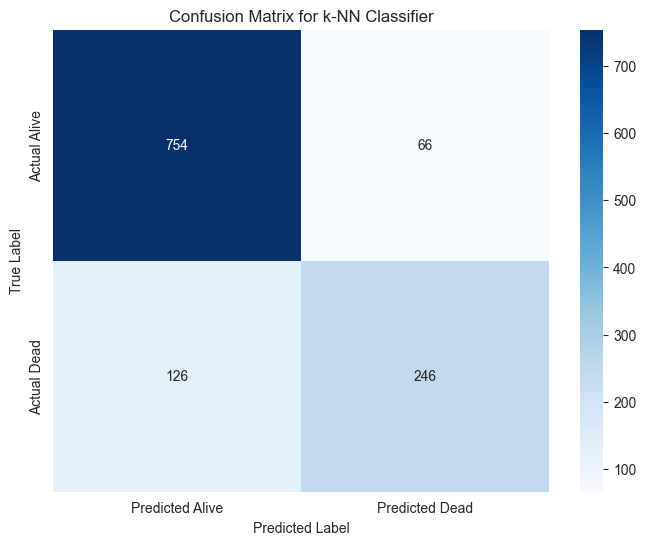

In [15]:
# Train the k-NN classifier with the optimal k
final_knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('classifier', KNeighborsClassifier(n_neighbors=best_k))])
final_knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = final_knn_pipeline.predict(X_test)

# Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize the Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Alive', 'Predicted Dead'],
            yticklabels=['Actual Alive', 'Actual Dead'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for k-NN Classifier')
plt.show()

# k-Nearest Neighbor Regressor for Life Expectancy

In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

# list of features
features = ['RIDAGEYR', 'RIDRETH1', 'BMXBMI', 'SMQ020', 'DIQ010', 'BPQ020', 'LBXTC', 'CVD_HISTORY']

# output
ly = df_model["PERMTH_INT"]
# inputs
lx = df_model.loc[:, features]
lu = MinMaxScaler().fit_transform(lx)

# train/test split
lu_train, lu_test, ly_train, ly_test = train_test_split(lu, ly, test_size=0.3, random_state=100)

# Selecting Optimal k
We will use a large range [3, 1000] of k values to find the best fit for our model. We aim to optimize our model by finding the k value with the lowest root mean squared error (RMSE). We select the optimal value of k by minimizing the test RMSE. Although smaller k values typically produce lower training RMSE, this can indicate overfitting. By using test RMSE, we ensure that the selected k generalizes well to unseen data and balances bias and variance.

In [45]:
from sklearn.metrics import root_mean_squared_error

k_grid = np.array([3, 5, 10, 15, 20, 25, 50, 75, 100, 250, 500, 1000]) # test k-values
rmses = [] # List to save RMSEs testing
rmses_train = [] # List to save RMSEs training
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(lu_train,ly_train)
    ly_hat = model.predict(lu_test)
    rmse_train = root_mean_squared_error(ly_train, model.predict(lu_train))
    rmses_train.append(rmse_train) # Save training RMSE
    rmse = root_mean_squared_error(ly_test, ly_hat)
    rmses.append(rmse) # Save test RMSE
    print( f'Test RMSE for {k} neighbors is {rmse}. Train RMSE for {k} neighbors is {rmse_train}.')

Test RMSE for 3 neighbors is 54.03127891709443. Train RMSE for 3 neighbors is 36.649925325693324.
Test RMSE for 5 neighbors is 50.71065307773574. Train RMSE for 5 neighbors is 40.66563040705108.
Test RMSE for 10 neighbors is 48.93975597369792. Train RMSE for 10 neighbors is 43.92452175619891.
Test RMSE for 15 neighbors is 48.64705574658486. Train RMSE for 15 neighbors is 45.22243082144612.
Test RMSE for 20 neighbors is 48.605292002562464. Train RMSE for 20 neighbors is 46.00445163398739.
Test RMSE for 25 neighbors is 48.94588953133268. Train RMSE for 25 neighbors is 46.51119685105927.
Test RMSE for 50 neighbors is 49.54527498652049. Train RMSE for 50 neighbors is 48.23214716795899.
Test RMSE for 75 neighbors is 49.563609977527605. Train RMSE for 75 neighbors is 48.25370431823504.
Test RMSE for 100 neighbors is 49.779252928782. Train RMSE for 100 neighbors is 48.67061418572635.
Test RMSE for 250 neighbors is 53.28126989928578. Train RMSE for 250 neighbors is 52.59724035909874.
Test RMSE

We plot our k value RMSE results in a scatter plot to visualize our RMSE results for k. We then find the minimum RMSE for our testing set to choose the optimal value of k.

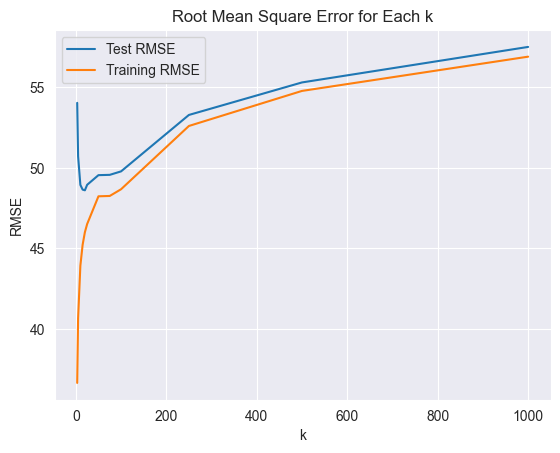

The optimal value for k is 20


In [47]:
sns.lineplot(x=k_grid, y=rmses, label = 'Test RMSE')
sns.lineplot(x=k_grid, y=rmses_train, label = 'Training RMSE')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('Root Mean Square Error for Each k')
plt.show()

is_optimal = rmses == np.min(rmses) # Minimizer Boolean
optimal_indices = np.where(is_optimal) # Indices that maximize accuracy
k_optimal = k_grid[optimal_indices] # Values of k that maximize accuracy
k_optimal = k_optimal[0]
print(f'The optimal value for k is {k_optimal}')

Finally, we fit the knn regressor and predict. We display a plot that shows the accuracy of our model by comparing the model's predicted values to the actual values. The predicted values generally follow the diagonal, indicating a positive relationship between actual and predicted survival time. However, there is noticeable spread, particularly at higher survival times, suggesting the model tends to underestimate longer survival durations. The model has a RMSE of 48.6, meaning predictions are typically within 49 months (roughly 4 years) of the actual survival time.

The RMSE for k=20 is 48.605292002562464.


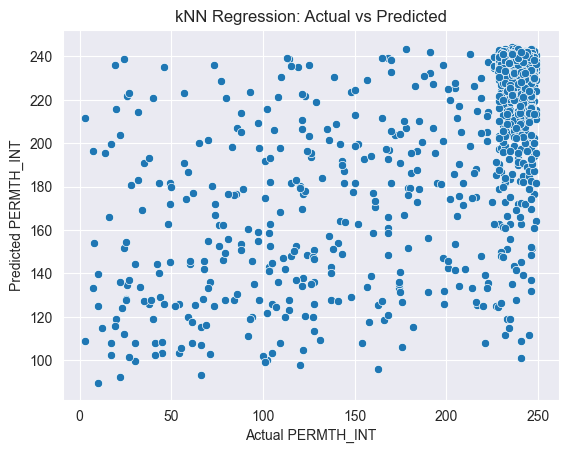

In [52]:
# train and predict
model = KNeighborsRegressor(n_neighbors = k_optimal)
model = model.fit(lu_train,ly_train)
ly_hat = model.predict(lu_test)
rmse = root_mean_squared_error(ly_test, model.predict(lu_test))

# show RMSE
print(f'The RMSE for k={k_optimal} is {rmse}.')

# Show accuracy plot
sns.scatterplot(x=ly_test, y=ly_hat)
plt.xlabel("Actual PERMTH_INT")
plt.ylabel("Predicted PERMTH_INT")
plt.title("kNN Regression: Actual vs Predicted")
plt.show()